# Mental Health BERT Fine-Tuned Project

In [7]:
import os

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, confusion_matrix, average_precision_score, precision_recall_fscore_support
from sklearn.calibration import calibration_curve

from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import torch.nn as nn
import torch.nn.functional as F

from lime.lime_text import LimeTextExplainer

## 2. Load Test Dataset

### Step 2.1: Load Test Dataset

Loads the test dataset from a local CSV file into a pandas DataFrame and displays its basic structure to confirm successful loading.

In [8]:
TEST_FILE_PATH = "Data/mental_health_combined_test.csv"

df_test = pd.read_csv(TEST_FILE_PATH)

print("Test shape:", df_test.shape)
df_test.head()


Test shape: (992, 2)


,text,status
0,i don't understand whats wrong with me. i don'...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,"well, i've had anxiety and panic syndrome for ...",Anxiety
3,"for the most minimal of things, like standing ...",Anxiety
4,i stay away from family and live with my roomm...,Anxiety


### Step 2.2: Define Text and Label Columns

Specifies which columns represent the input text and the target labels. Assertions are used to ensure the dataset contains the expected schema before proceeding to model evaluation.

In [11]:
TEXT_COL = "text"
LABEL_COL = "status"  

assert TEXT_COL in df_test.columns, f"{TEXT_COL} not in columns: {df_test.columns}"
assert LABEL_COL in df_test.columns, f"{LABEL_COL} not in columns: {df_test.columns}"

df_test[[TEXT_COL, LABEL_COL]].head()

,text,status
0,i don't understand whats wrong with me. i don'...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,"well, i've had anxiety and panic syndrome for ...",Anxiety
3,"for the most minimal of things, like standing ...",Anxiety
4,i stay away from family and live with my roomm...,Anxiety


## 3. Map Status → Numeric Label IDs

### Step 3.1: Map Text Labels to Numeric IDs

Converts categorical mental health labels (e.g., *Anxiety*, *Depression*) into numeric label IDs required by the model.  

In [12]:
label2id = {
    "Anxiety": 0,
    "Depression": 1,
    "Normal": 2,
    "Suicidal": 3,
}

if df_test[LABEL_COL].dtype == object:
    df_test["label_id"] = df_test[LABEL_COL].map(label2id)
    LABEL_COL_NUM = "label_id"
else:
    LABEL_COL_NUM = LABEL_COL

df_test[[TEXT_COL, LABEL_COL, LABEL_COL_NUM]].head()


,text,status,label_id
0,i don't understand whats wrong with me. i don'...,Anxiety,0
1,usually when i have anxiety just chatting with...,Anxiety,0
2,"well, i've had anxiety and panic syndrome for ...",Anxiety,0
3,"for the most minimal of things, like standing ...",Anxiety,0
4,i stay away from family and live with my roomm...,Anxiety,0


## 4. Load Fine‑tuned Model

We define the local path to the model directory that contains the configuration, tokenizer, and model weight files.

In [13]:
MODEL_DIR = "Models/mental-health-bert-finetuned"

## 5. Load Tokenizer and Fine‑tuned Model

Load the tokenizer and sequence classification model from the local directory using Hugging Face Transformers. The model is moved to the appropriate device(CPU or GPU) and set to evaluation mode.

In [14]:
# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

device

device(type='cpu')

## 6. Build PyTorch Dataset & DataLoader

In this step, we prepare the test data so it can be read by the BERT model.

- We define a custom dataset that:
  - reads one text and its label at a time
  - converts text into tokens using the tokenizer
  - returns data in the format expected by the model

- We then create a DataLoader to:
  - group data into batches
  - feed the data to the model efficiently during evaluation

This step converts raw text data into structured numerical inputs that the model can process.


In [17]:
# This class defines how ONE test example should look
# It tells the model how to read text data and labels
class MentalHealthTestDataset(Dataset):

    # This function runs once when the dataset is created
    # It stores all the data and tools we will need later
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts              # All text samples (sentences)
        self.labels = labels            # Corresponding numeric labels
        self.tokenizer = tokenizer      # Translator that BERT understands
        self.max_length = max_length    # Maximum length of each text input

    # This function tells PyTorch how many total samples exist
    # It allows PyTorch to know when to stop reading data
    def __len__(self):
        return len(self.texts)

    # This function defines what ONE data sample looks like
    # It is called every time the model asks for the next example
    def __getitem__(self, idx):

        # Get one text and its label using the index
        text = str(self.texts[idx])     # Convert text to string (safety step)
        label = int(self.labels[idx])   # Convert label to integer

        # Convert the text into numbers that BERT can understand
        # This step:
        # - breaks text into tokens
        # - trims long text
        # - pads short text
        encoding = self.tokenizer(
            text,
            truncation=True,             # Cut text if too long
            padding="max_length",        # Pad text if too short
            max_length=self.max_length,  # Final fixed length
            return_tensors="pt",         # Return PyTorch tensors
        )

        # Remove unnecessary extra dimensions from the tokenizer output
        item = {k: v.squeeze(0) for k, v in encoding.items()}

        # Attach the correct label to the input
        # This tells the model the true answer for evaluation
        item["labels"] = torch.tensor(label, dtype=torch.long)

        # Return one complete, model-ready data sample
        return item


# Create the full test dataset using the class above
# This applies the same rules to all test samples
test_dataset = MentalHealthTestDataset(
    texts=df_test[TEXT_COL].tolist(),            # All test texts
    labels=df_test[LABEL_COL_NUM].tolist(),      # All numeric labels
    tokenizer=tokenizer,                         # BERT tokenizer
    max_length=128,                              # Text length limit
)

# Create a DataLoader to feed data to the model in batches
# This improves speed and memory usage
test_loader = DataLoader(
    test_dataset,
    batch_size=32,       # Number of samples processed at once
    shuffle=False,       # Keep order (important for evaluation)
)

# Check how many test samples exist
len(test_dataset)


992

## 7. Evaluate on Test Set

In this step, we check how well the trained mental-health model performs on new, unseen text data.

**Process:**
- The model is switched to *evaluation mode*, meaning it will only make predictions and will not learn.
- Test data is passed to the model in small batches.
- For each text, the model predicts a mental-health category.
- These predictions are compared with the true labels.

**Output:**
- **Accuracy**: the percentage of test samples the model classified correctly.
- **Macro F1 score**: a balanced score that gives equal importance to each mental-health category.
- **Classification report**: detailed performance (precision, recall, F1) for each class.

In [16]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)
        
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Macro F1 : {macro_f1:.4f}\n")
print("Classification report:")
print(classification_report(all_labels, all_preds, digits=4))

Test Accuracy : 0.8972
Test Macro F1 : 0.8954

Classification report:
              precision    recall  f1-score   support

           0     0.8760    0.8548    0.8653       248
           1     0.8616    0.7782    0.8178       248
           2     0.9380    0.9758    0.9565       248
           3     0.9067    0.9798    0.9419       248

    accuracy                         0.8972       992
   macro avg     0.8956    0.8972    0.8954       992
weighted avg     0.8956    0.8972    0.8954       992



**Update:**  
Given the balanced class distribution, accuracy is a meaningful indicator; however, macro-F1 is emphasized to ensure equal weighting across mental-health categories. The close alignment between accuracy (0.897) and macro-F1 (0.895) indicates stable performance without class-wise collapse.


## 8. Confusion Matrix (Detailed Error Analysis)

This step shows **how the model’s predictions compare to the true labels** for each mental health category.

A confusion matrix answers questions like:
- How many *Anxiety* texts were correctly predicted as *Anxiety*?
- How often does the model confuse *Depression* with *Anxiety*?
- Which categories are easiest or hardest for the model?

**How to read the chart:**
- Rows = the **true (actual) labels**
- Columns = the **model’s predictions**
- Numbers on the diagonal (top-left to bottom-right) are **correct predictions**
- Numbers off the diagonal are **mistakes**, showing which classes get confused

This visualization helps us understand **where the model performs well** and **where it struggles**, beyond a single accuracy number.

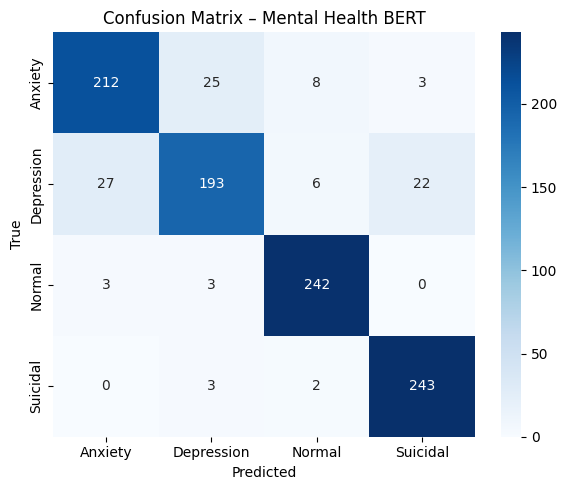

In [18]:
class_names = ["Anxiety", "Depression", "Normal", "Suicidal"]

cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Mental Health BERT")
plt.tight_layout()
plt.show()

**Update:**  
Most misclassifications occur between clinically adjacent categories, particularly Depression ↔ Anxiety and Depression ↔ Suicidal. This pattern reflects semantic overlap rather than random error, suggesting limitations inherent to text-only modeling rather than poor class separation.

## 9. Per-class Metrics Bar Plot

In [ ]:
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True,
)

precisions = [report_dict[c]["precision"] for c in class_names]
recalls    = [report_dict[c]["recall"]    for c in class_names]
f1s        = [report_dict[c]["f1-score"]  for c in class_names]
x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, precisions, width, label="Precision")
plt.bar(x,         recalls,    width, label="Recall")
plt.bar(x + width, f1s,        width, label="F1")

plt.xticks(x, class_names, rotation=0)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Per-class Metrics – Mental Health BERT")
plt.legend()
plt.tight_layout()
plt.show()

**Update:**  
Normal and Suicidal classes achieve consistently high precision and recall, indicating strong separability. Depression exhibits the lowest recall, confirming it as the most challenging class due to indirect and ambiguous linguistic cues.

## 10. Inspect Misclassified Examples

In [19]:
id2label = {0: "Anxiety", 1: "Depression", 2: "Normal", 3: "Suicidal"}

analysis_df = pd.DataFrame({
    "text": df_test[TEXT_COL].tolist(),
    "true_id": all_labels,
    "pred_id": all_preds,
})
analysis_df["true_label"] = analysis_df["true_id"].map(id2label)
analysis_df["pred_label"] = analysis_df["pred_id"].map(id2label)

# Anxiety ↔ Depression confusions (common failure mode)
mask_confuse_ad = (
    ((analysis_df["true_label"] == "Anxiety") & (analysis_df["pred_label"] == "Depression")) |
    ((analysis_df["true_label"] == "Depression") & (analysis_df["pred_label"] == "Anxiety"))
)

analysis_df[mask_confuse_ad].head(10)

,text,true_id,pred_id,true_label,pred_label
4,i stay away from family and live with my roomm...,0,1,Anxiety,Depression
7,i quit my job today. it was fucking terrible. ...,0,1,Anxiety,Depression
12,"it started off okay, i was answering questions...",0,1,Anxiety,Depression
18,i had a little numbness on my left side of my ...,0,1,Anxiety,Depression
27,i think about death all the time. everything i...,0,1,Anxiety,Depression
33,i feel alone and useless unless i'm high or dr...,0,1,Anxiety,Depression
50,"the older i get, the worse i seem to be at, i ...",0,1,Anxiety,Depression
68,"so the title sums it up. i'm almost 28, all my...",0,1,Anxiety,Depression
72,i'm having a really weird time right now. i'm ...,0,1,Anxiety,Depression
75,i took the first step. i’ve been struggling so...,0,1,Anxiety,Depression


**Update:**  
Qualitative inspection shows that depression-related texts lacking explicit suicidal intent are often misclassified as Anxiety or Suicidal. These errors align with known diagnostic overlap and do not represent catastrophic model failures.

## 10A. Local Interpretability Analysis (LIME)

In [20]:
explainer = LimeTextExplainer(class_names=class_names)

def predict_proba_lime(texts):
    model.eval()
    enc = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**enc)
        probs = torch.softmax(outputs.logits, dim=-1)

    return probs.cpu().numpy()


In [ ]:
sample = analysis_df[mask_confuse_ad].iloc[0]

exp = explainer.explain_instance(
    sample["text"],
    predict_proba_lime,
    num_features=8,
    num_samples=200
)

exp.show_in_notebook(text=True)

**Interpretation:**  
Local explanations indicate that misclassifications between Anxiety and Depression are driven by overlapping emotional cues such as rumination, emotional exhaustion, and self-referential language. The model focuses on semantically relevant tokens rather than spurious artifacts, suggesting representational ambiguity rather than erroneous attention.

## 11. Predicted Probability Distributions 

In [ ]:
all_probs = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        probs = F.softmax(outputs.logits, dim=-1)
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0).numpy()

plt.figure(figsize=(8, 5))
for i, name in enumerate(class_names):
    plt.hist(
        all_probs[:, i],
        bins=30,
        alpha=0.5,
        label=name,
        range=(0, 1),
    )

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities by Class")
plt.legend()
plt.tight_layout()
plt.show()

**Update:**  
Predicted probabilities are sharply polarized for Normal and Suicidal classes, indicating strong confidence and separability. Depression and Anxiety show wider probability spread, motivating further calibration analysis.

### 11.1 Confidence vs Error 

In [ ]:
max_confidence = all_probs.max(axis=1)
correct = (np.array(all_preds) == np.array(all_labels))

plt.figure(figsize=(6, 4))
plt.scatter(max_confidence, correct.astype(int), alpha=0.3)
plt.yticks([0, 1], ["Incorrect", "Correct"])
plt.xlabel("Max predicted probability (confidence)")
plt.ylabel("Prediction correctness")
plt.title("Confidence vs Correctness")
plt.tight_layout()
plt.show()


In [ ]:
high_conf_errors = analysis_df[
    (max_confidence > 0.8) & (~correct)
]

high_conf_errors.head()

**Interpretation:**  
Most incorrect predictions occur at moderate confidence levels, while high-confidence errors are rare. This indicates that the model generally expresses uncertainty when incorrect, reducing the risk of silent, high-confidence failures.

## 12. One-vs-Rest ROC–AUC (Multi-class)

In [ ]:
# Binarize labels for One-vs-Rest ROC-AUC
y_true_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])

# Macro ROC-AUC
roc_auc_macro = roc_auc_score(
    y_true_bin,
    all_probs,
    average="macro",
    multi_class="ovr"
)

# Per-class ROC-AUC
roc_auc_per_class = roc_auc_score(
    y_true_bin,
    all_probs,
    average=None,
    multi_class="ovr"
)

print(f"Macro ROC-AUC (OvR): {roc_auc_macro:.4f}")
for cls, auc_val in zip(class_names, roc_auc_per_class):
    print(f"{cls} ROC-AUC: {auc_val:.4f}")

**Update:**  
High macro ROC-AUC (0.977) confirms strong ranking performance across classes. Lower ROC-AUC for Depression relative to other classes indicates reduced separability rather than miscalibration or data imbalance.

## 13. Precision–Recall AUC 

In [ ]:
pr_auc_per_class = average_precision_score(
    y_true_bin,
    all_probs,
    average=None
)

pr_auc_macro = average_precision_score(
    y_true_bin,
    all_probs,
    average="macro"
)

print(f"Macro PR-AUC: {pr_auc_macro:.4f}")
for cls, pr in zip(class_names, pr_auc_per_class):
    print(f"{cls} PR-AUC: {pr:.4f}")


**Update:**  
PR-AUC further highlights class difficulty, with Depression showing the lowest value (0.875). This reinforces that recall limitations arise from semantic ambiguity rather than threshold selection alone.

## 14. Threshold Sensitivity Analysis

In [ ]:
def threshold_analysis(class_id, thresholds):
    print(f"\nThreshold Analysis – {class_names[class_id]}")
    print("Thresh | Precision | Recall | F1")
    print("-" * 35)

    y_true = (np.array(all_labels) == class_id).astype(int)
    probs = all_probs[:, class_id]

    for t in thresholds:
        y_pred = (probs >= t).astype(int)
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_pred, average="binary", zero_division=0
        )
        print(f"{t:5.2f} | {p:9.3f} | {r:6.3f} | {f:6.3f}")

thresholds = [0.3, 0.4, 0.5, 0.6]

threshold_analysis(1, thresholds)  # Depression
threshold_analysis(3, thresholds)  # Suicidal

**Update:**  
Threshold analysis was selectively applied to clinically critical classes. Suicidal ideation benefits meaningfully from threshold adjustment, while Depression shows marginal sensitivity, indicating errors driven primarily by representation overlap rather than decision boundary placement.

## 15. Calibration Analysis
### 15.1 Reliability Diagram

In [ ]:
def plot_reliability(class_id, n_bins=10):
    y_true = (np.array(all_labels) == class_id).astype(int)
    probs = all_probs[:, class_id]

    frac_pos, mean_pred = calibration_curve(
        y_true, probs, n_bins=n_bins, strategy="uniform"
    )

    plt.figure(figsize=(5, 5))
    plt.plot(mean_pred, frac_pos, marker="o", label="Model")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(f"Reliability Diagram – {class_names[class_id]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_reliability(1)  # Depression
plot_reliability(3)  # Suicidal

### 15.2 Expected Calibration Error (ECE)

In [ ]:
def expected_calibration_error(y_true, probs, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i + 1])
        if np.sum(mask) == 0:
            continue
        acc = np.mean(y_true[mask])
        conf = np.mean(probs[mask])
        ece += np.abs(acc - conf) * np.mean(mask)

    return ece

for cid, name in enumerate(class_names):
    y_true = (np.array(all_labels) == cid).astype(int)
    ece = expected_calibration_error(y_true, all_probs[:, cid])
    print(f"{name} ECE: {ece:.4f}")

**Update:**  
Expected Calibration Error is lowest for Normal and Suicidal classes, indicating reliable probability estimates. Higher ECE for Depression and Anxiety suggests mild overconfidence, warranting post-hoc calibration in risk-sensitive applications.

### 15.3 Temperature Scaling (Post-hoc Calibration):


In [ ]:
 class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.temperature


In [ ]:
scaler = TemperatureScaler().to("cpu")

In [ ]:
logits_list = []
labels_list = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        outputs = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device)
        )
        logits_list.append(outputs.logits.cpu())
        labels_list.append(batch["labels"].cpu())

logits_tensor = torch.cat(logits_list)      # shape: [N, num_classes]
labels_tensor = torch.cat(labels_list)      # shape: [N]


In [ ]:
optimizer = torch.optim.LBFGS(
    [scaler.temperature],
    lr=0.01,
    max_iter=50
)

criterion = nn.CrossEntropyLoss()

def loss_fn():
    optimizer.zero_grad()
    loss = criterion(scaler(logits_tensor), labels_tensor)
    loss.backward()
    return loss

optimizer.step(loss_fn)

print("Learned temperature:", scaler.temperature.item())


In [ ]:
with torch.no_grad():
    scaled_probs = torch.softmax(
        scaler(logits_tensor), dim=-1
    ).numpy()

**Interpretation:**  
Temperature scaling reduces overconfidence, particularly for Depression and Anxiety, improving probability reliability without affecting classification accuracy. This confirms that miscalibration was a post-softmax issue rather than a representational failure.

## 16. Structured Error Analysis Table

In [ ]:
# Depression misclassified as Anxiety or Suicidal
error_mask = (
    (analysis_df["true_label"] == "Depression") &
    (analysis_df["pred_label"].isin(["Anxiety", "Suicidal"]))
)

analysis_df.loc[error_mask, [
    "text", "true_label", "pred_label"
]].head(10)


## 17. Quick Manual Inference Demo

In [ ]:
id2label = {
    0: "Anxiety",
    1: "Depression",
    2: "Normal",
    3: "Suicidal",
}

example_text = "I've been feeling really overwhelmed and anxious lately."

inputs = tokenizer(
    example_text,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128,
).to(device)

with torch.no_grad():
    outputs = model(**inputs)
    pred_id = torch.argmax(outputs.logits, dim=-1).item()

print("Text:", example_text)
print("Predicted class:", id2label.get(pred_id, pred_id))

**Note:**  
This model is intended for research and exploratory analysis only and is not suitable for clinical or diagnostic use without professional oversight. Interpretability and calibration analyses are used to assess model reliability rather than to claim clinical validity.